# Building a Perceptron

In this notebook, you will implement a perceptron from scratch and apply it to a binary classification problem.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [15]:
def perceptron(x, w, b):
    
    """A single perceptron neuron.

    Parameters
    ----------
    x : array-like, shape (n_features,)
        Input features.
    w : array-like, shape (n_features,)
        Weights.
    b : float
        Bias.

    Returns
    -------
    int
        1 if the weighted sum + bias >= 0, else 0.
    """
    z = np.dot(x, w) + b
    return 1 if z >= 0 else 0


# --- Place both a cost function and your update rule function here ---
#
# Cost function: because the perceptron outputs hard 0/1 values (not
# probabilities), we cannot use cross-entropy (log(0) is undefined).
# Instead, define a cost function that counts the total number of
# misclassifications over a dataset:
#   cost(X, y, w, b) = sum of (y_i != y_hat_i) for all examples
# This is what we will plot to monitor training progress.
def cost(X, y, w, b):
    # Initialize cost
    cost = 0
    for i in range (len(X)):
        y_hat = perceptron(X[i], w, b)
        if y[i] != y_hat:
            cost += 1
    return cost 


#
# Update rule: implement the perceptron training rule.
#   w_i <- w_i + eta * (y - y_hat) * x_i
#   b   <- b   + eta * (y - y_hat)
# where eta is the learning rate, y is the true label, and y_hat is
# the prediction.

def trainingrule(x, y, w, b, eta):
    if perceptron(x, w, b) != y:
        w = w + eta*(y - perceptron(x, w, b))*x
        b = b + eta*(y - perceptron(x, w, b))
    return w, b

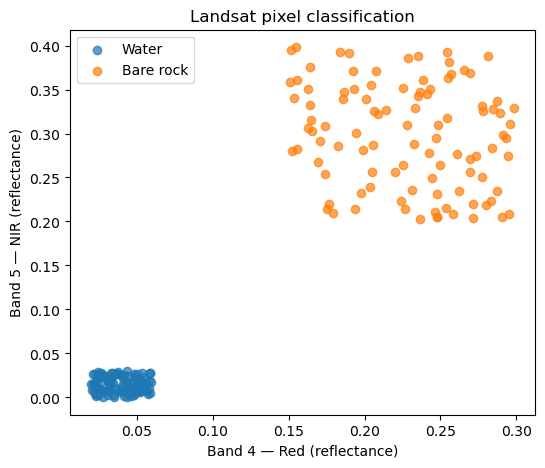

In [16]:
# Synthetic Landsat surface reflectance (SR) dataset.
# Two classes: water vs. bare rock, using Band 4 (Red) and Band 5 (NIR).
#
# SR values range from 0 to 1. Typical ranges for these land-cover types:
#
#   Water     — Visible (Blue/Green): 0.02–0.10
#               NIR & SWIR: ~0.0 (water absorbs nearly all infrared light)
#
#   Bare rock — Visible: 0.15–0.30
#               SWIR: 0.20–0.40+
#


np.random.seed(42)
n_samples = 200

# Class 0: water pixels
water_red = np.random.uniform(0.02, 0.06, n_samples // 2)
water_nir = np.random.uniform(0.00, 0.03, n_samples // 2)
X_water = np.column_stack([water_red, water_nir])

# Class 1: bare rock pixels
rock_red = np.random.uniform(0.15, 0.30, n_samples // 2)
rock_nir = np.random.uniform(0.20, 0.40, n_samples // 2)
X_rock = np.column_stack([rock_red, rock_nir])

X = np.vstack([X_water, X_rock])
y = np.concatenate([np.zeros(n_samples // 2), np.ones(n_samples // 2)])

plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Water", alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Bare rock", alpha=0.7)
plt.xlabel("Band 4 — Red (reflectance)")
plt.ylabel("Band 5 — NIR (reflectance)")
plt.title("Landsat pixel classification")
plt.legend()
plt.show()

In [17]:
# Split the data into training, validation, and test sets.
#
# The validation set is used to monitor performance during training.
# When the validation loss starts to increase (while training loss
# keeps decreasing), this signals overfitting --- a good time to stop.

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Training:   {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Test:       {len(X_test)} samples")

Training:   120 samples
Validation: 40 samples
Test:       40 samples


In [22]:
# Training loop

eta = 0.1          # learning rate
n_epochs = 50      # maximum number of passes through the training set

# Initialize weights and bias
w = np.zeros(X_train.shape[1])
b = 0.0

val_costs = []      # store validation cost at each epoch

for epoch in range(n_epochs):

    # Iterate through each training example
    for i in range(len(X_train)):
        w, b = trainingrule(X_train[i], y_train[i], w, b, eta)

    # Validation check: compute the cost on the validation set
    # --- Use your cost function here ---
    val_cost = cost(X_val, y_val, w, b)
    val_costs.append(val_cost)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1:3d} | Validation cost: {val_cost}")

# --- How well does your model do on your test set? ---
print("Test Set Cost:")
print(cost(X_test, y_test, w, b))

Epoch  10 | Validation cost: 0
Epoch  20 | Validation cost: 0
Epoch  30 | Validation cost: 0
Epoch  40 | Validation cost: 0
Epoch  50 | Validation cost: 0
Test Set Cost:
0


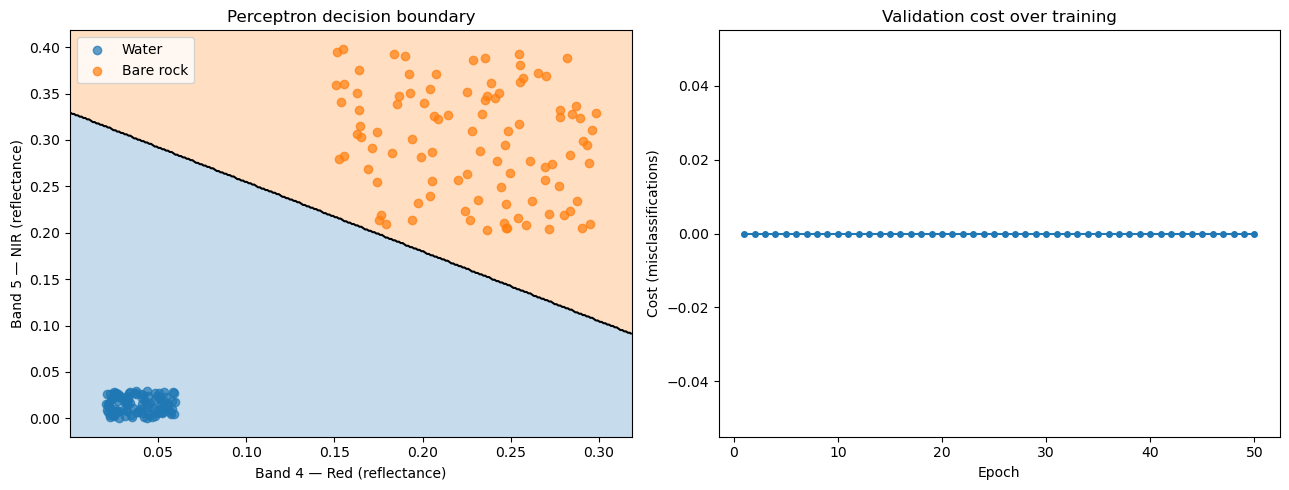

In [23]:
# Plot the decision boundary and validation cost

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left panel: decision boundary ---
ax = axes[0]

# Create a mesh over the feature space
x_min, x_max = X[:, 0].min() - 0.02, X[:, 0].max() + 0.02
y_min, y_max = X[:, 1].min() - 0.02, X[:, 1].max() + 0.02
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300),
)

# Predict on the mesh
Z = np.array([perceptron(np.array([xi, yi]), w, b)
              for xi, yi in zip(xx.ravel(), yy.ravel())])
Z = Z.reshape(xx.shape)

ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.25,
            colors=["#1f77b4", "#ff7f0e"])
ax.contour(xx, yy, Z, levels=[0.5], colors="k", linewidths=1.5)
ax.scatter(X[y == 0, 0], X[y == 0, 1], label="Water", alpha=0.7)
ax.scatter(X[y == 1, 0], X[y == 1, 1], label="Bare rock", alpha=0.7)
ax.set_xlabel("Band 4 — Red (reflectance)")
ax.set_ylabel("Band 5 — NIR (reflectance)")
ax.set_title("Perceptron decision boundary")
ax.legend()

# --- Right panel: validation cost vs. epoch ---
ax = axes[1]
ax.plot(range(1, len(val_costs) + 1), val_costs, "o-", markersize=4)
ax.set_xlabel("Epoch")
ax.set_ylabel("Cost (misclassifications)")
ax.set_title("Validation cost over training")

plt.tight_layout()
plt.show()